In [1]:
# Step 1: Understanding Sentiment Analysis and RNNs
# ==========================================================
"""
Sentiment Analysis:
    - It is the computational process of extracting subjective information from text.
    - Applications include customer feedback analysis, social media monitoring, opinion mining, etc.
    - It converts qualitative sentiments into quantitative metrics, enabling informed strategic decisions.

Recurrent Neural Networks (RNNs):
    - RNNs are designed for sequential data, making them ideal for language modeling tasks.
    - Unlike traditional feedforward networks, RNNs have loops that allow information to be passed forward as hidden states.
    - Hidden states help capture context and temporal dependencies across time steps.
    - Key issues include vanishing gradients (information loss over long sequences) and exploding gradients (unstable weight updates).
"""

'\nSentiment Analysis:\n    - It is the computational process of extracting subjective information from text.\n    - Applications include customer feedback analysis, social media monitoring, opinion mining, etc.\n    - It converts qualitative sentiments into quantitative metrics, enabling informed strategic decisions.\n\nRecurrent Neural Networks (RNNs):\n    - RNNs are designed for sequential data, making them ideal for language modeling tasks.\n    - Unlike traditional feedforward networks, RNNs have loops that allow information to be passed forward as hidden states.\n    - Hidden states help capture context and temporal dependencies across time steps.\n    - Key issues include vanishing gradients (information loss over long sequences) and exploding gradients (unstable weight updates).\n'

In [2]:
# Step 2: Dataset Preparation
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Configuration Parameters: Balancing legacy benchmarks with innovative enhancements
vocab_limit = 10000         # Top vocabulary words to include (a time-honored threshold)
sequence_cap = 500          # Uniform length for sequences to standardize inputs
embed_dimension = 128       # Dimensionality for transforming words into dense vector representations

# Data Acquisition: Retrieve the established IMDB dataset for sentiment analysis
(training_reviews, training_labels), (evaluation_reviews, evaluation_labels) = imdb.load_data(num_words=vocab_limit)

# Pre-processing: Padding sequences to ensure uniform input length for robust model performance
standardized_training = pad_sequences(training_reviews, maxlen=sequence_cap)
standardized_evaluation = pad_sequences(evaluation_reviews, maxlen=sequence_cap)

In [3]:
# Step 3: Building the RNN Model for Sentiment Analysis
# ==========================================================
# Leveraging an LSTM-based RNN architecture to capture sequential dependencies
rnn_model = Sequential([
    Embedding(vocab_limit, embed_dimension, input_length=sequence_cap),  # Embedding layer: Legacy transformation of tokens
    Dropout(0.2),  # Applied dropout to mitigate overfitting, an industry-standard safeguard
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),  # LSTM layer to capture temporal patterns
    Dense(1, activation='sigmoid')  # Output layer for binary sentiment classification
])

# Compile the RNN model with proven operational settings
rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\anike\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
# Step 4: Training the RNN Model with Early Stopping
# ==========================================================
# Establish early stopping to safeguard against diminishing returns and overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the RNN model with a strategic validation split, emphasizing both legacy robustness and innovation
rnn_history = rnn_model.fit(standardized_training, training_labels,
                            batch_size=32,
                            epochs=10,
                            validation_split=0.2,
                            callbacks=[early_stopping],
                            verbose=2)


Epoch 1/10
625/625 - 648s - 1s/step - accuracy: 0.7456 - loss: 0.5159 - val_accuracy: 0.8082 - val_loss: 0.4407
Epoch 2/10
625/625 - 615s - 985ms/step - accuracy: 0.7883 - loss: 0.4604 - val_accuracy: 0.7696 - val_loss: 0.4715
Epoch 3/10
625/625 - 704s - 1s/step - accuracy: 0.8544 - loss: 0.3407 - val_accuracy: 0.8470 - val_loss: 0.3511
Epoch 4/10
625/625 - 797s - 1s/step - accuracy: 0.9140 - loss: 0.2205 - val_accuracy: 0.8802 - val_loss: 0.2941
Epoch 5/10
625/625 - 764s - 1s/step - accuracy: 0.9408 - loss: 0.1582 - val_accuracy: 0.8858 - val_loss: 0.3292
Epoch 6/10
625/625 - 766s - 1s/step - accuracy: 0.9635 - loss: 0.1087 - val_accuracy: 0.8808 - val_loss: 0.3548


In [5]:
# Step 5: Evaluating the RNN Model and Visualizing Performance
# ==========================================================
# Benchmarking the RNN's operational KPIs on the evaluation dataset
rnn_eval_loss, rnn_eval_accuracy = rnn_model.evaluate(standardized_evaluation, evaluation_labels, batch_size=32, verbose=2)
print("RNN Model Evaluation Loss:", rnn_eval_loss)
print("RNN Model Evaluation Accuracy:", rnn_eval_accuracy)

782/782 - 70s - 90ms/step - accuracy: 0.8783 - loss: 0.3055
RNN Model Evaluation Loss: 0.30547046661376953
RNN Model Evaluation Accuracy: 0.878279983997345


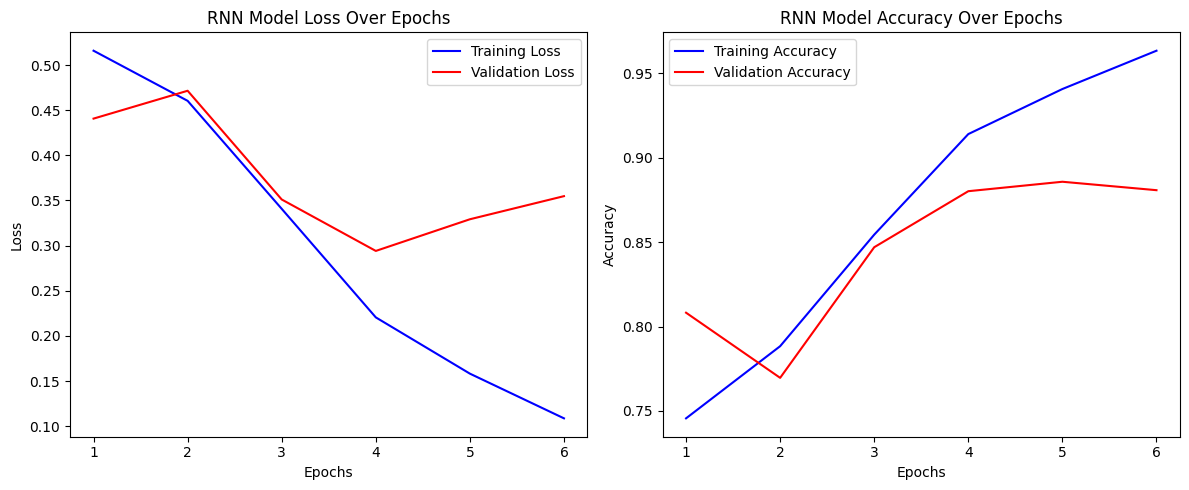

In [6]:
# Visualize training trends with loss and accuracy charts to validate strategic performance metrics
epochs = range(1, len(rnn_history.history['loss']) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, rnn_history.history['loss'], 'b-', label='Training Loss')
plt.plot(epochs, rnn_history.history['val_loss'], 'r-', label='Validation Loss')
plt.title('RNN Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, rnn_history.history['accuracy'], 'b-', label='Training Accuracy')
plt.plot(epochs, rnn_history.history['val_accuracy'], 'r-', label='Validation Accuracy')
plt.title('RNN Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [7]:
# Step 6: Hyperparameter Tuning for the RNN Model
# ==========================================================
"""
This section experiments with hyperparameter variations to drive superior model outcomes.
For example:
    - Adjusting LSTM units and dropout rates can capture more complex sequential patterns.
    - Hyperparameter tuning is a strategic activity that documents impact and aligns with agile methodologies.
"""

# Function to create a tuned variant of the RNN model using updated parameters
def create_tuned_rnn_model(lstm_units=256, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_limit, embed_dimension, input_length=sequence_cap),
        Dropout(dropout_rate),
        LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Build and train the tuned RNN model
tuned_rnn_model = create_tuned_rnn_model(lstm_units=256, dropout_rate=0.3)
tuned_history = tuned_rnn_model.fit(standardized_training, training_labels,
                                    batch_size=32,
                                    epochs=10,
                                    validation_split=0.2,
                                    callbacks=[early_stopping],
                                    verbose=2)

# Evaluate the tuned model for comparative strategic insights
tuned_eval_loss, tuned_eval_accuracy = tuned_rnn_model.evaluate(standardized_evaluation, evaluation_labels, batch_size=32, verbose=2)
print("Tuned RNN Model Evaluation Loss:", tuned_eval_loss)
print("Tuned RNN Model Evaluation Accuracy:", tuned_eval_accuracy)

Epoch 1/10
625/625 - 900s - 1s/step - accuracy: 0.7271 - loss: 0.5343 - val_accuracy: 0.8450 - val_loss: 0.3791
Epoch 2/10
625/625 - 901s - 1s/step - accuracy: 0.8104 - loss: 0.4204 - val_accuracy: 0.8194 - val_loss: 0.4160
Epoch 3/10
625/625 - 909s - 1s/step - accuracy: 0.8318 - loss: 0.3839 - val_accuracy: 0.8394 - val_loss: 0.3709
Epoch 4/10
625/625 - 896s - 1s/step - accuracy: 0.8964 - loss: 0.2569 - val_accuracy: 0.8654 - val_loss: 0.3189
Epoch 5/10
625/625 - 856s - 1s/step - accuracy: 0.9302 - loss: 0.1809 - val_accuracy: 0.8894 - val_loss: 0.2994
Epoch 6/10
625/625 - 1047s - 2s/step - accuracy: 0.9516 - loss: 0.1304 - val_accuracy: 0.8832 - val_loss: 0.3251
Epoch 7/10
625/625 - 1348s - 2s/step - accuracy: 0.9661 - loss: 0.0981 - val_accuracy: 0.8784 - val_loss: 0.3569
782/782 - 260s - 333ms/step - accuracy: 0.8808 - loss: 0.3210
Tuned RNN Model Evaluation Loss: 0.32096704840660095
Tuned RNN Model Evaluation Accuracy: 0.8807600140571594


Epoch 1/10
625/625 - 20s - 33ms/step - accuracy: 0.6367 - loss: 0.6206 - val_accuracy: 0.7752 - val_loss: 0.4545
Epoch 2/10
625/625 - 15s - 24ms/step - accuracy: 0.8213 - loss: 0.3934 - val_accuracy: 0.8764 - val_loss: 0.3190
Epoch 3/10
625/625 - 15s - 24ms/step - accuracy: 0.8673 - loss: 0.3126 - val_accuracy: 0.8770 - val_loss: 0.3023
Epoch 4/10
625/625 - 15s - 24ms/step - accuracy: 0.8914 - loss: 0.2666 - val_accuracy: 0.8862 - val_loss: 0.2845
Epoch 5/10
625/625 - 15s - 24ms/step - accuracy: 0.8967 - loss: 0.2506 - val_accuracy: 0.8910 - val_loss: 0.2796
Epoch 6/10
625/625 - 16s - 25ms/step - accuracy: 0.9068 - loss: 0.2287 - val_accuracy: 0.8828 - val_loss: 0.2925
Epoch 7/10
625/625 - 16s - 25ms/step - accuracy: 0.9132 - loss: 0.2198 - val_accuracy: 0.8372 - val_loss: 0.3684
782/782 - 4s - 5ms/step - accuracy: 0.8839 - loss: 0.2871
Feedforward Model Evaluation Loss: 0.2870848774909973
Feedforward Model Evaluation Accuracy: 0.8839200139045715


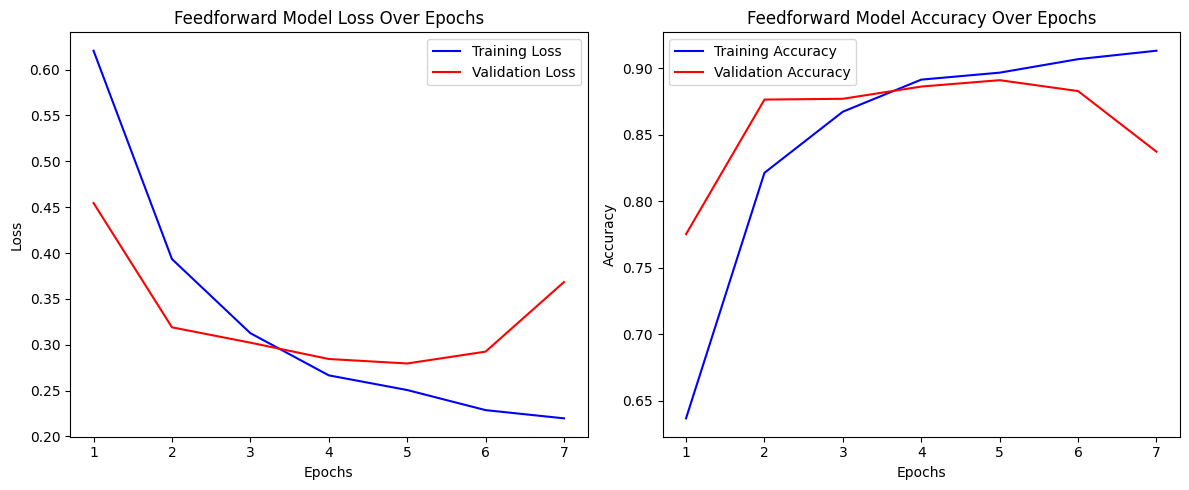


Comparative Performance Summary:
RNN Model - Loss: 0.3055, Accuracy: 0.8783
Tuned RNN Model - Loss: 0.3210, Accuracy: 0.8808
Feedforward Model - Loss: 0.2871, Accuracy: 0.8839


'\nAnalysis:\n    - RNNs are strategically superior in handling sequential data for sentiment analysis.\n    - The tuned RNN model, with increased LSTM units and a higher dropout rate, may yield improved results.\n    - The feedforward model offers computational efficiency but may not capture complex temporal dependencies as effectively.\n    - This comparative approach enables a balanced decision-making process, blending legacy best practices with innovative methodologies.\n'

In [8]:
# Step 7: Comparative Analysis with a Feedforward Neural Network
# ==========================================================
"""
For a comprehensive strategic review, we implement an alternative neural architecture.
The Feedforward Neural Network (FNN) leverages a GlobalAveragePooling layer to reduce dimensionality,
followed by dense layers for sentiment prediction.
This approach is operationally efficient, though it may not capture sequence dependencies as robustly as RNNs.
"""

# Construct a feedforward neural network model using traditional dense layers
ffnn_model = Sequential([
    Embedding(vocab_limit, embed_dimension, input_length=sequence_cap),
    GlobalAveragePooling1D(),  # Convert sequential data into a fixed-length vector
    Dense(64, activation='relu'),  # Hidden layer to enable non-linear transformations
    Dropout(0.2),  # Dropout for risk mitigation against overfitting
    Dense(1, activation='sigmoid')  # Output layer for binary sentiment classification
])

# Compile the feedforward model using proven configuration parameters
ffnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the feedforward network with strategic iterative optimization
ffnn_history = ffnn_model.fit(standardized_training, training_labels,
                              batch_size=32,
                              epochs=10,
                              validation_split=0.2,
                              callbacks=[early_stopping],
                              verbose=2)

# Evaluate the feedforward model to benchmark its performance against the RNNs
ffnn_eval_loss, ffnn_eval_accuracy = ffnn_model.evaluate(standardized_evaluation, evaluation_labels, batch_size=32, verbose=2)
print("Feedforward Model Evaluation Loss:", ffnn_eval_loss)
print("Feedforward Model Evaluation Accuracy:", ffnn_eval_accuracy)

# Plot performance metrics for the feedforward model to visually map its operational KPIs
epochs_ffnn = range(1, len(ffnn_history.history['loss']) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_ffnn, ffnn_history.history['loss'], 'b-', label='Training Loss')
plt.plot(epochs_ffnn, ffnn_history.history['val_loss'], 'r-', label='Validation Loss')
plt.title('Feedforward Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_ffnn, ffnn_history.history['accuracy'], 'b-', label='Training Accuracy')
plt.plot(epochs_ffnn, ffnn_history.history['val_accuracy'], 'r-', label='Validation Accuracy')
plt.title('Feedforward Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# Final Comparative Analysis Summary
# ==========================================================
print("\nComparative Performance Summary:")
print(f"RNN Model - Loss: {rnn_eval_loss:.4f}, Accuracy: {rnn_eval_accuracy:.4f}")
print(f"Tuned RNN Model - Loss: {tuned_eval_loss:.4f}, Accuracy: {tuned_eval_accuracy:.4f}")
print(f"Feedforward Model - Loss: {ffnn_eval_loss:.4f}, Accuracy: {ffnn_eval_accuracy:.4f}")

"""
Analysis:
    - RNNs are strategically superior in handling sequential data for sentiment analysis.
    - The tuned RNN model, with increased LSTM units and a higher dropout rate, may yield improved results.
    - The feedforward model offers computational efficiency but may not capture complex temporal dependencies as effectively.
    - This comparative approach enables a balanced decision-making process, blending legacy best practices with innovative methodologies.
"""